In [26]:
#Redirecting to Project Base

import os 
import sys
from pathlib import Path
BASE = Path.cwd().parent.parent.parent
sys.path.insert(0, str(BASE))

In [27]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Importing Classes
from src.data import Data

In [28]:
data_handler = Data()

Loading data...
Data loaded succesfully!


In [47]:
product_id = 'HOBBIES_1_147_CA_1_validation'

In [48]:
df = data_handler.get_train_data(product_id, choice = 'single_prod_day_wise')

In [50]:
df.T

,142
d_1,0
d_2,0
d_3,0
d_4,0
d_5,0
...,...
d_1909,3
d_1910,11
d_1911,7
d_1912,6


In [51]:
sales = df.iloc[0].values

In [52]:
sales

array([0, 0, 0, ..., 7, 6, 9], shape=(1913,))

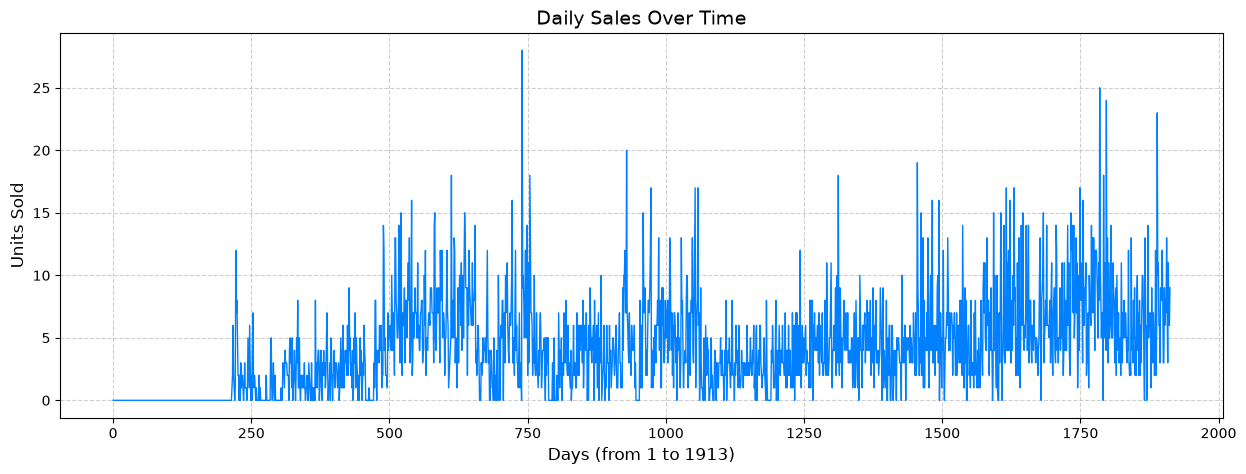

In [53]:
plt.figure(figsize=(15, 5))
plt.plot(sales, color="#0080ff", linewidth=1)

plt.title("Daily Sales Over Time", fontsize=14)
plt.xlabel("Days (from 1 to 1913)", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [54]:
sales_series = pd.Series(sales)

In [55]:
sales_series

0        0
1        0
2        0
3        0
4        0
        ..
1908     3
1909    11
1910     7
1911     6
1912     9
Length: 1913, dtype: int64

In [56]:
sma_7 = sales_series.rolling(window=7).mean().round(2).astype("Float64")
sma_30 = sales_series.rolling(window=30).mean().round(2).astype("Float64")
sma_60 = sales_series.rolling(window=60).mean().round(2).astype("Float64")
sma_100 = sales_series.rolling(window=100).mean().round(2).astype("Float64")

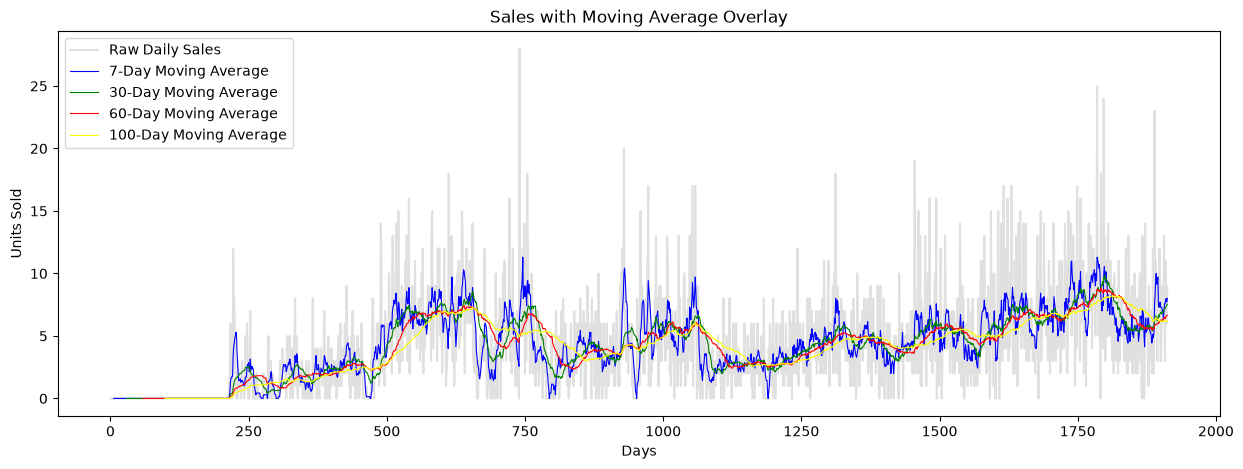

In [57]:
plt.figure(figsize=(15, 5))
plt.plot(sales_series, color='lightgrey', label='Raw Daily Sales', alpha=0.7)
plt.plot(sma_7, color='blue', label='7-Day Moving Average', linewidth=0.8)
plt.plot(sma_30, color='green', label='30-Day Moving Average', linewidth=0.8)
plt.plot(sma_60, color='red', label='60-Day Moving Average', linewidth=0.8)
plt.plot(sma_100, color='yellow', label='100-Day Moving Average', linewidth=0.8)


plt.title("Sales with Moving Average Overlay")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

In [59]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Hides convergence warnings

# 1. Define the MA order (q). Let's use q=7 for a weekly error memory.
q = 7 

# 2. Fit the MA(q) model. (ARIMA with p=0, d=0, q=7)
# Note: Real MA modeling requires stationary data, but we are keeping it simple here.
model = ARIMA(sales_series, order=(0, 0, q))
ma_fit = model.fit()

# 3. Forecast the next 28 days
#forecast_28_days = ma_fit.forecast(steps=28).astype("int")
forecast_28_days = ma_fit.forecast(steps=130)

print("Forecast for the next 28 days:")
print(forecast_28_days)

Forecast for the next 28 days:
1913    6.138590
1914    4.860876
1915    5.094725
1916    5.228382
1917    4.536729
          ...   
2038    4.165347
2039    4.165347
2040    4.165347
2041    4.165347
2042    4.165347
Name: predicted_mean, Length: 130, dtype: float64
